In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from google.colab import drive

# Menyambungkan ke Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/DATASET_KELULUSAN/dataset_kelulusan.csv')

# Lihat isi data
print(df.head())
print(df.info())

   tahun_masuk  bulan_lulus     ipk jumlah_mk_gagal sks_lulus status_skripsi  \
0         2021            1  Sedang         Sedikit     Cukup         Semhas   
1         2018           12  Sedang         Sedikit     Cukup         Sempro   
2         2020            6  Rendah         Sedikit    Kurang       JudulAcc   
3         2018            5  Sedang         Sedikit    Kurang         Semhas   
4         2017            7  Tinggi         Sedikit     Cukup         Semhas   

  jumlah_bimbingan label_tepat_waktu  
0           Banyak             Tidak  
1           Banyak                Ya  
2          Sedikit             Tidak  
3           Banyak                Ya  
4           Banyak             Tidak  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   tahun_masuk        1000 non-null   int64 
 1   bulan_lulus        1000 non-null  

In [3]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   tahun_masuk  bulan_lulus  ipk  jumlah_mk_gagal  sks_lulus  status_skripsi  \
0            5            0    1                1          0               2   
1            2           11    1                1          0               3   
2            4            5    0                1          1               1   
3            2            4    1                1          1               2   
4            1            6    2                1          0               2   

   jumlah_bimbingan  label_tepat_waktu  
0                 0                  0  
1                 0                  1  
2                 1                  0  
3                 0                  1  
4                 0                  0  


In [4]:
X = df.drop('label_tepat_waktu', axis=1)
y = df['label_tepat_waktu']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
import joblib
from sklearn.tree import DecisionTreeClassifier
from google.colab import files

# Define and train the model
model = DecisionTreeClassifier(
    criterion='entropy',   # bisa ganti 'gini'
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

# Save the model
joblib.dump(model, 'model_kelulusan.pkl')
files.download('model_kelulusan.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
model = DecisionTreeClassifier(
    criterion='entropy',   # bisa ganti 'gini'
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

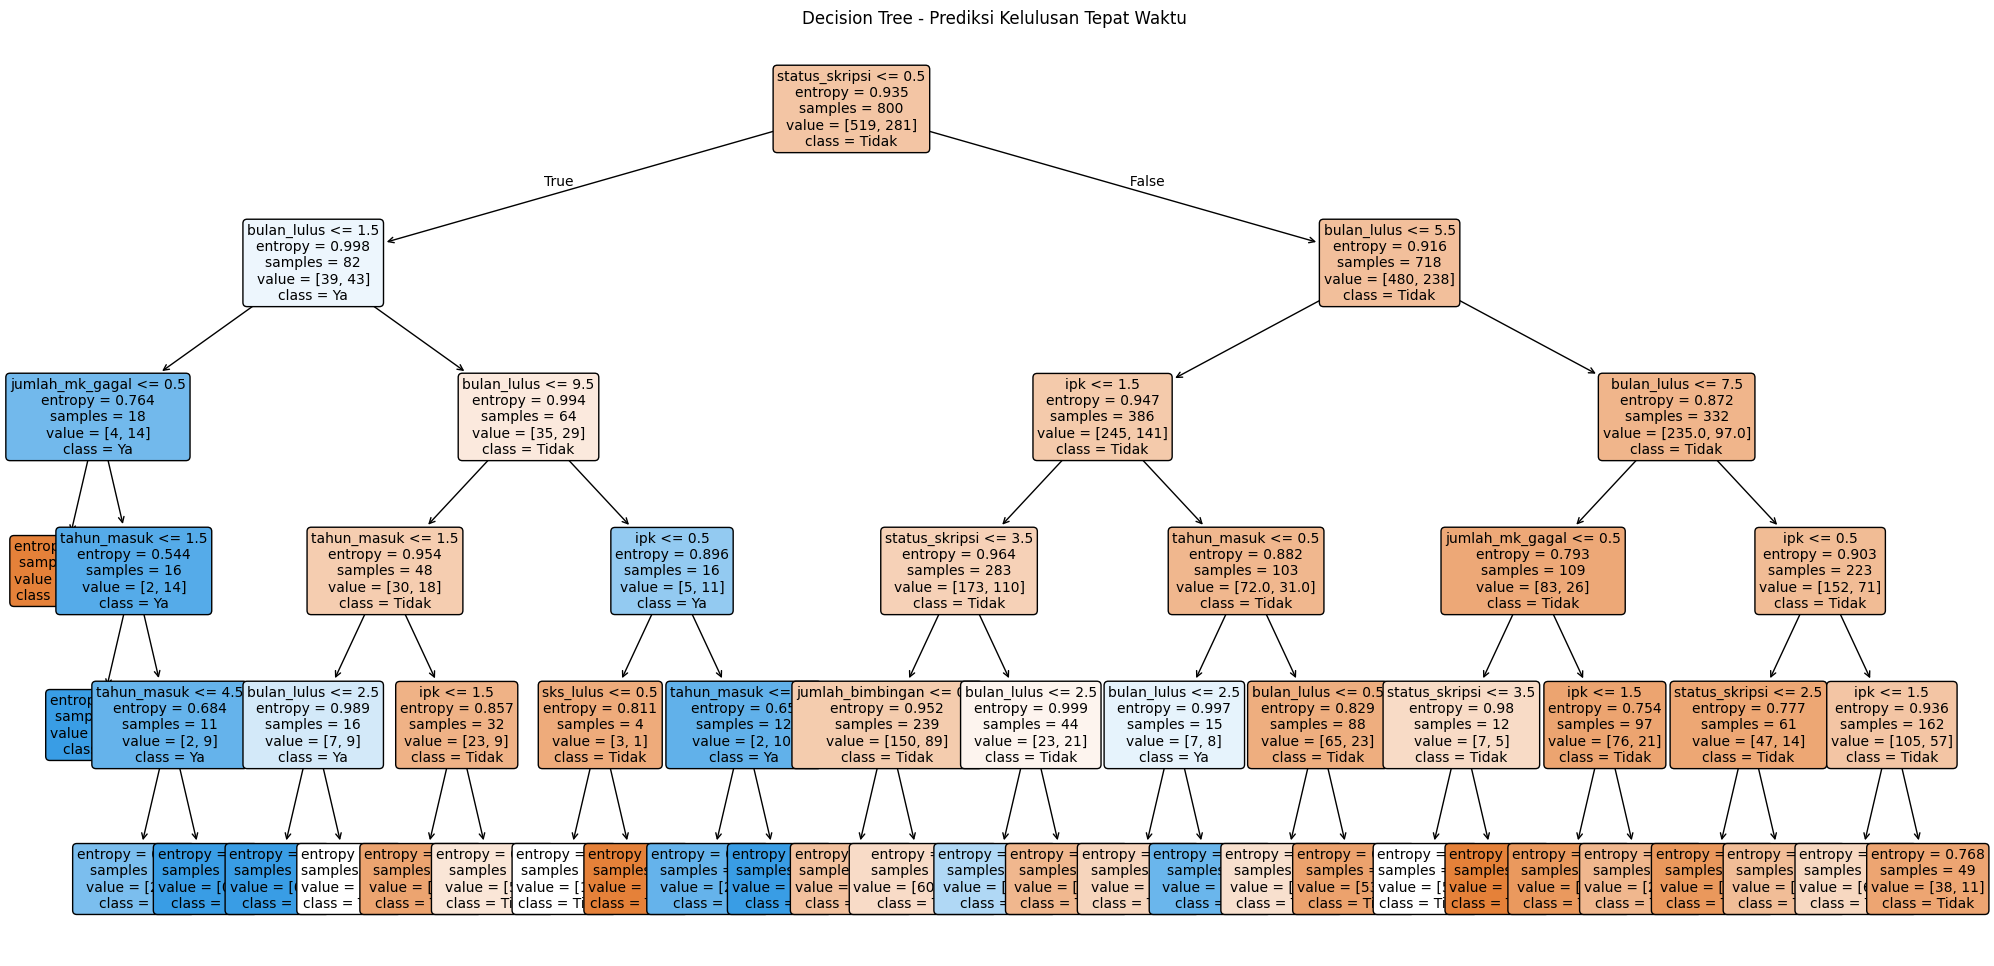

In [8]:
plt.figure(figsize=(25,12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Tidak", "Ya"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree - Prediksi Kelulusan Tepat Waktu")
plt.show()

In [9]:
y_pred = model.predict(X_test)

print("Contoh hasil prediksi:", y_pred[:10])

Contoh hasil prediksi: [0 0 1 0 0 0 0 0 0 0]


In [10]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.645
Confusion Matrix:
 [[125   6]
 [ 65   4]]
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.95      0.78       131
           1       0.40      0.06      0.10        69

    accuracy                           0.65       200
   macro avg       0.53      0.51      0.44       200
weighted avg       0.57      0.65      0.55       200

